Epoch 1/3
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.2425 - val_loss: 0.1631
Epoch 2/3
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.1434 - val_loss: 0.1257
Epoch 3/3
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.1176 - val_loss: 0.1083
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step


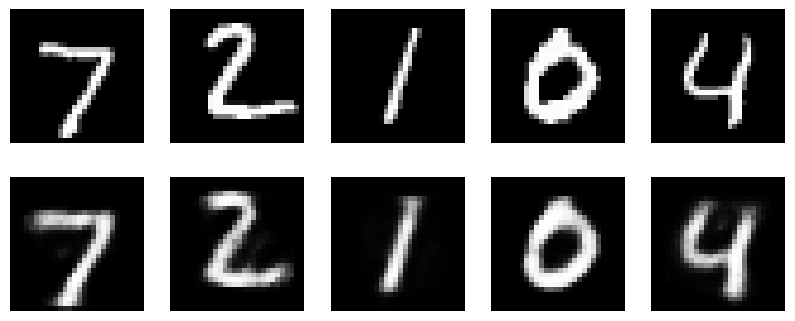

In [14]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

# Load Data
(x_train, _), (x_test, _) = mnist.load_data()
x_train, x_test = x_train/255.0, x_test/255.0
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# Autoencoder Model
inp = layers.Input(shape=(28,28,1))
x = layers.Flatten()(inp)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dense(28*28, activation='sigmoid')(x)
out = layers.Reshape((28,28,1))(x)
autoencoder = models.Model(inp, out)

# Compile + Train
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
autoencoder.fit(x_train, x_train, epochs=3, batch_size=256, validation_data=(x_test, x_test))

# Predict + Show
decoded = autoencoder.predict(x_test[:5])
plt.figure(figsize=(10,4))
for i in range(5):
    plt.subplot(2,5,i+1); plt.imshow(x_test[i].reshape(28,28), cmap='gray'); plt.axis('off')
    plt.subplot(2,5,i+6); plt.imshow(decoded[i].reshape(28,28), cmap='gray'); plt.axis('off')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step


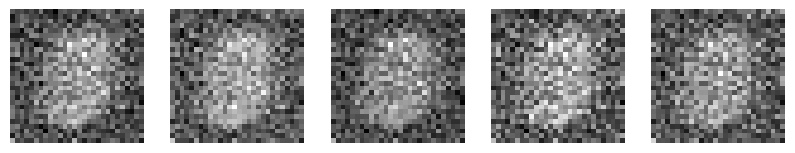

In [15]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

# Load Data
(x_train, _), (_, _) = mnist.load_data()
x_train = (x_train.astype(np.float32)-127.5)/127.5
x_train = np.expand_dims(x_train, axis=-1)

# Generator
generator = models.Sequential([
    layers.Input(shape=(100,)),
    layers.Dense(256, activation='relu'),
    layers.Dense(784, activation='tanh'),
    layers.Reshape((28,28,1))
])

# Discriminator
discriminator = models.Sequential([
    layers.Input(shape=(28,28,1)),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])
discriminator.compile(optimizer='adam', loss='binary_crossentropy')

# GAN
discriminator.trainable = False
gan_input = layers.Input(shape=(100,))
gan = models.Model(gan_input, discriminator(generator(gan_input)))
gan.compile(optimizer='adam', loss='binary_crossentropy')

# Training
for epoch in range(500):
    idx = np.random.randint(0, x_train.shape[0], 32)
    real = x_train[idx]
    noise = np.random.normal(0, 1, (32, 100))
    fake = generator.predict(noise, verbose=0)
    discriminator.trainable = True
    discriminator.train_on_batch(real, np.ones((32,1)))
    discriminator.train_on_batch(fake, np.zeros((32,1)))
    discriminator.trainable = False
    gan.train_on_batch(noise, np.ones((32,1)))

# Generate + Show
noise = np.random.normal(0, 1, (5, 100))
gen_imgs = generator.predict(noise)
plt.figure(figsize=(10,2))
for i in range(5):
    plt.subplot(1,5,i+1); plt.imshow(gen_imgs[i].reshape(28,28), cmap='gray'); plt.axis('off')
plt.show()